# Cleaning

In [2]:
import pandas as pd
import numpy as np

In [3]:
movies = pd.read_csv("FullMovieDataset.csv")

In [4]:
movies.columns

Index(['adult', 'id', 'original_language', 'overview', 'popularity',
       'release_date', 'title', 'vote_average', 'vote_count',
       'belongs_to_collection_boolean', 'budget', 'genres', 'origin_country',
       'production_companies', 'revenue', 'runtime', 'num_spoken_languages',
       'reddit_sentiment_weighted', 'RottenTomatoesScore'],
      dtype='object')

In [5]:
movies.shape

(954, 19)

In [6]:
movies.columns = ['Adult',
                  'Id',
                  'OriginalLanguage',
                  'Overview',
                  'Popularity',
                  'ReleaseDate',
                  'Title',
                  'VoteAverage',
                  'VoteCount',
                  'BelongsToCollectionBoolean',
                  'Budget',
                  'Genres',
                  'OriginCountry',
                  'ProductionCompanies',
                  'Revenue',
                  'Runtime',
                  'NumSpokenLanguages',
                  'RedditSentimentWeighted',
                  'RottenTomatoesScore']

In [7]:
movies.apply(lambda x: sum(x == 0))

Adult                         954
Id                              0
OriginalLanguage                0
Overview                        0
Popularity                      0
ReleaseDate                     0
Title                           0
VoteAverage                     0
VoteCount                       0
BelongsToCollectionBoolean    701
Budget                        415
Genres                          0
OriginCountry                   0
ProductionCompanies             0
Revenue                       429
Runtime                         4
NumSpokenLanguages             10
RedditSentimentWeighted         4
RottenTomatoesScore             0
dtype: int64

In [8]:
movies.VoteAverage.mean()

6.54279035639413

In [9]:
movies = movies[movies['Revenue'] != 0]

In [10]:
movies.shape

(525, 19)

In [11]:
movies.apply(lambda x: sum(pd.isnull(x)))

Adult                          0
Id                             0
OriginalLanguage               0
Overview                       0
Popularity                     0
ReleaseDate                    0
Title                          0
VoteAverage                    0
VoteCount                      0
BelongsToCollectionBoolean     0
Budget                         0
Genres                         0
OriginCountry                  0
ProductionCompanies            0
Revenue                        0
Runtime                        0
NumSpokenLanguages             0
RedditSentimentWeighted       52
RottenTomatoesScore           73
dtype: int64

In [12]:
movies.VoteAverage.mean()

7.065478095238095

In [13]:
movies = movies[(movies['RedditSentimentWeighted'].notnull()) & (movies['RedditSentimentWeighted'] != 0)]

In [14]:
movies.VoteAverage.mean()

7.184713983050848

In [15]:
movies = movies[movies["RottenTomatoesScore"].notnull()]

In [16]:
movies["RottenTomatoesScore"] = movies.copy()["RottenTomatoesScore"].str.strip("%").astype(int) / 100

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
movies[['VoteAverage',
        'RedditSentimentWeighted',
        'RottenTomatoesScore']] = scaler.fit_transform(movies[['VoteAverage',
                                                               'RedditSentimentWeighted',
                                                               'RottenTomatoesScore']])


# EDA

In [19]:
movies.shape

(441, 19)

In [20]:
movies.dtypes

Adult                            bool
Id                              int64
OriginalLanguage               object
Overview                       object
Popularity                    float64
ReleaseDate                    object
Title                          object
VoteAverage                   float64
VoteCount                       int64
BelongsToCollectionBoolean       bool
Budget                          int64
Genres                         object
OriginCountry                  object
ProductionCompanies            object
Revenue                         int64
Runtime                         int64
NumSpokenLanguages              int64
RedditSentimentWeighted       float64
RottenTomatoesScore           float64
dtype: object

In [21]:
movies.isnull().sum()

Adult                         0
Id                            0
OriginalLanguage              0
Overview                      0
Popularity                    0
ReleaseDate                   0
Title                         0
VoteAverage                   0
VoteCount                     0
BelongsToCollectionBoolean    0
Budget                        0
Genres                        0
OriginCountry                 0
ProductionCompanies           0
Revenue                       0
Runtime                       0
NumSpokenLanguages            0
RedditSentimentWeighted       0
RottenTomatoesScore           0
dtype: int64

In [22]:
movies.describe()

,Id,Popularity,VoteAverage,VoteCount,Budget,Revenue,Runtime,NumSpokenLanguages,RedditSentimentWeighted,RottenTomatoesScore
count,4.410000e+02,441.000000,441.000000,441.000000,4.410000e+02,4.410000e+02,441.000000,441.000000,441.000000,441.000000
mean,2.506788e+05,26.627329,0.752621,6477.503401,4.491737e+07,2.161382e+08,119.879819,1.759637,0.464790,0.755556
std,3.384707e+05,48.137720,0.217492,7547.491288,6.656697e+07,3.939169e+08,25.898080,1.270756,0.159087,0.278186
min,1.100000e+01,0.008400,0.000000,100.000000,0.000000e+00,3.000000e+00,68.000000,1.000000,0.000000,0.000000
25%,1.091000e+03,3.901400,0.718193,1047.000000,3.000000e+06,1.046250e+07,100.000000,1.000000,0.372625,0.690000
50%,2.896600e+04,13.134500,0.794462,3127.000000,1.640000e+07,5.169116e+07,117.000000,1.000000,0.449741,0.880000
75%,4.265630e+05,29.262200,0.898420,9499.000000,6.000000e+07,2.450664e+08,134.000000,2.000000,0.559481,0.940000
max,1.249213e+06,482.761300,1.000000,37430.000000,4.600000e+08,2.923706e+09,229.000000,9.000000,1.000000,1.000000


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

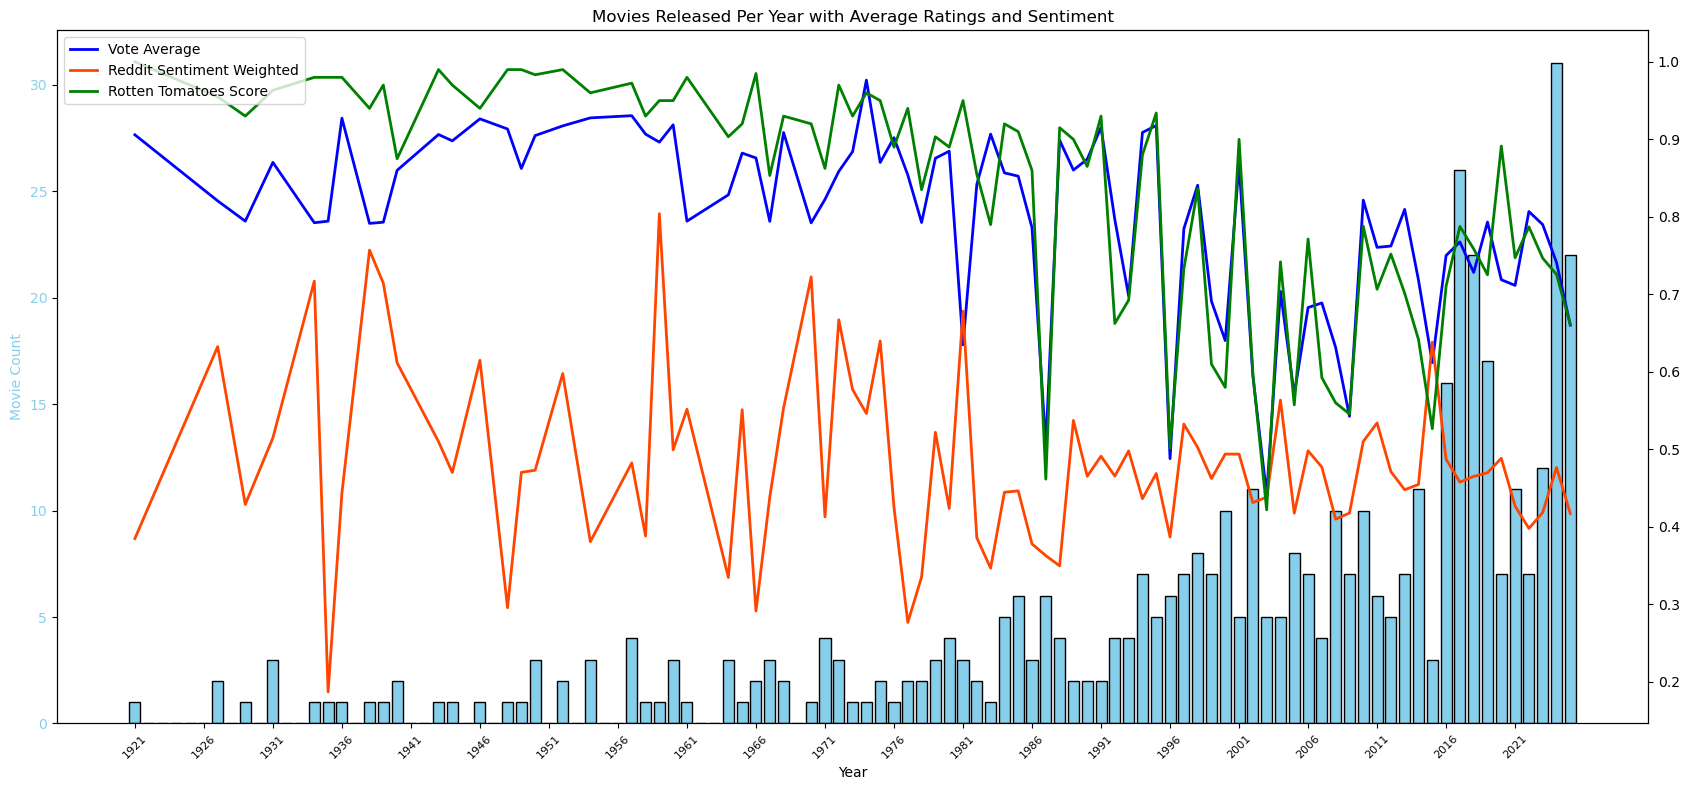

In [167]:
movies['ReleaseDate'] = pd.to_datetime(movies['ReleaseDate'], errors='coerce')
movies['ReleaseYear'] = movies['ReleaseDate'].dt.year

movies = movies.dropna(subset=['ReleaseYear'])
movies['ReleaseYear'] = movies['ReleaseYear'].astype(int)

yearly_counts = movies['ReleaseYear'].value_counts().sort_index()

full_year_range = np.arange(movies['ReleaseYear'].min(), movies['ReleaseYear'].max() + 1)
yearly_counts = yearly_counts.reindex(full_year_range, fill_value=0)

total_movies = yearly_counts.sum()
yearly_freq = yearly_counts / total_movies

yearly_avgs = movies.groupby('ReleaseYear')[['VoteAverage', 'RedditSentimentWeighted', 'RottenTomatoesScore']].mean()
yearly_avgs = yearly_avgs.reindex(full_year_range)

yearly_avgs_interp = yearly_avgs.interpolate(method='linear', limit_direction='both')

fig, ax1 = plt.subplots(figsize=(17, 8))

bars = ax1.bar(yearly_counts.index, yearly_counts.values, color='skyblue', edgecolor='black')
ax1.set_xlabel('Year')
ax1.set_ylabel('Movie Count', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(yearly_counts.index[::5])
ax1.set_xticklabels(yearly_counts.index[::5], rotation=45, fontsize=8)

ax2 = ax1.twinx()


line1, = ax2.plot(yearly_avgs_interp.index, yearly_avgs_interp['VoteAverage'], color='blue', label='Vote Average', linewidth=2)
line2, = ax2.plot(yearly_avgs_interp.index, yearly_avgs_interp['RedditSentimentWeighted'], color='orangered', label='Reddit Sentiment Weighted', linewidth=2)
line3, = ax2.plot(yearly_avgs_interp.index, yearly_avgs_interp['RottenTomatoesScore'], color='green', label='Rotten Tomatoes Score', linewidth=2)

ax2.legend(handles=[line1, line2, line3], loc='upper left')

plt.title('Movies Released Per Year with Average Ratings and Sentiment')
plt.tight_layout()
plt.show()

### Distribution of Numerical Columns

In [26]:
columns_of_choice = ['VoteAverage', 'RedditSentimentWeighted', 'RottenTomatoesScore']

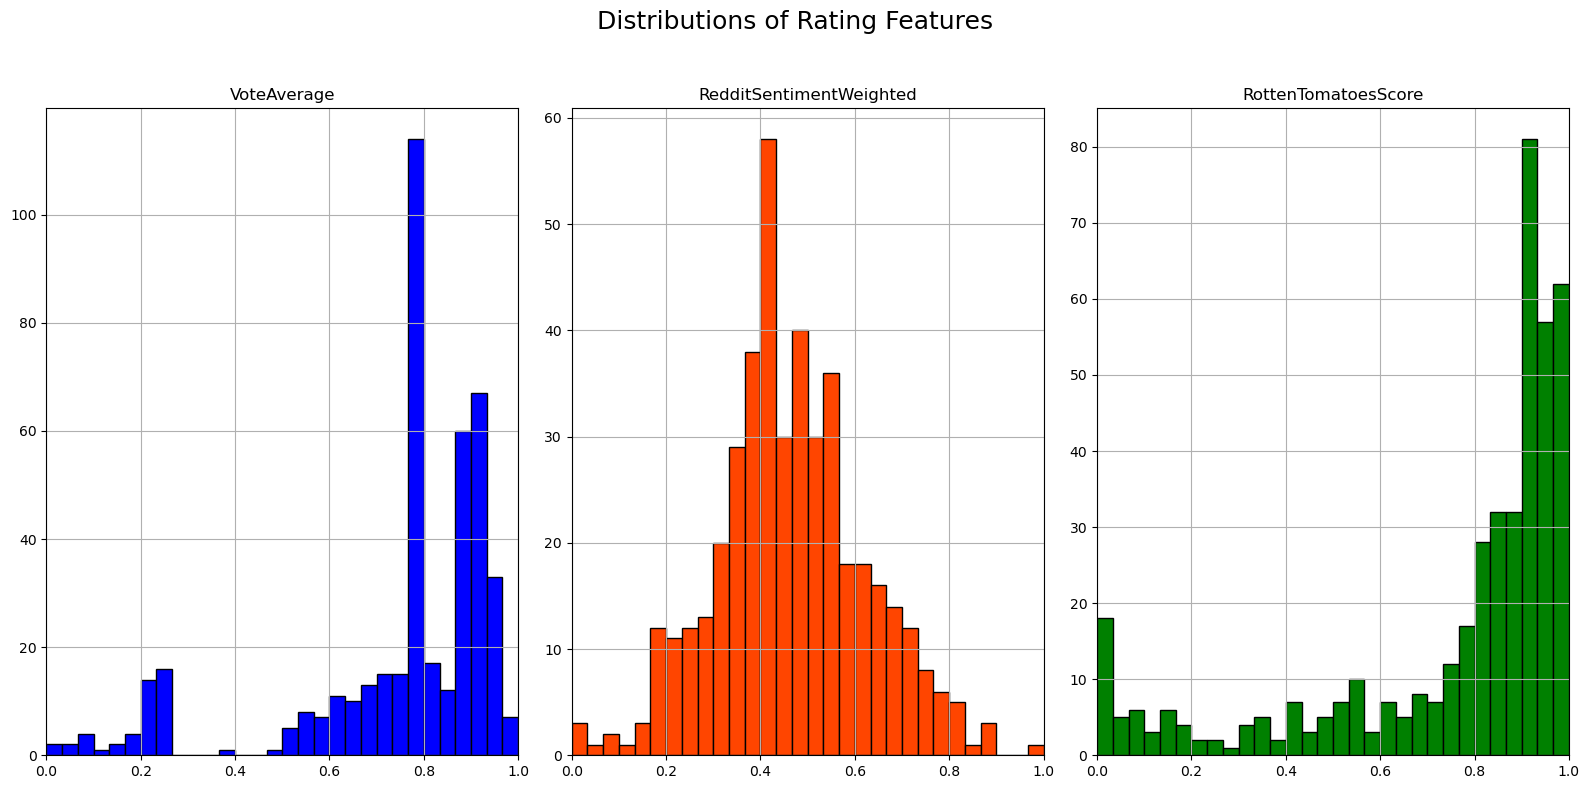

In [27]:
import matplotlib.pyplot as plt

colors = ['blue', 'orangered', 'green']
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharex=True)

xmin = movies[columns_of_choice].min().min()
xmax = movies[columns_of_choice].max().max()

for ax, col, color in zip(axes, columns_of_choice, colors):
    movies[col].hist(bins=30, color=color, edgecolor='black', ax=ax)
    ax.set_xlim(xmin, xmax)
    ax.set_title(col)

plt.suptitle('Distributions of Rating Features', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [28]:
columns_of_choice = ['Popularity', 'VoteCount']

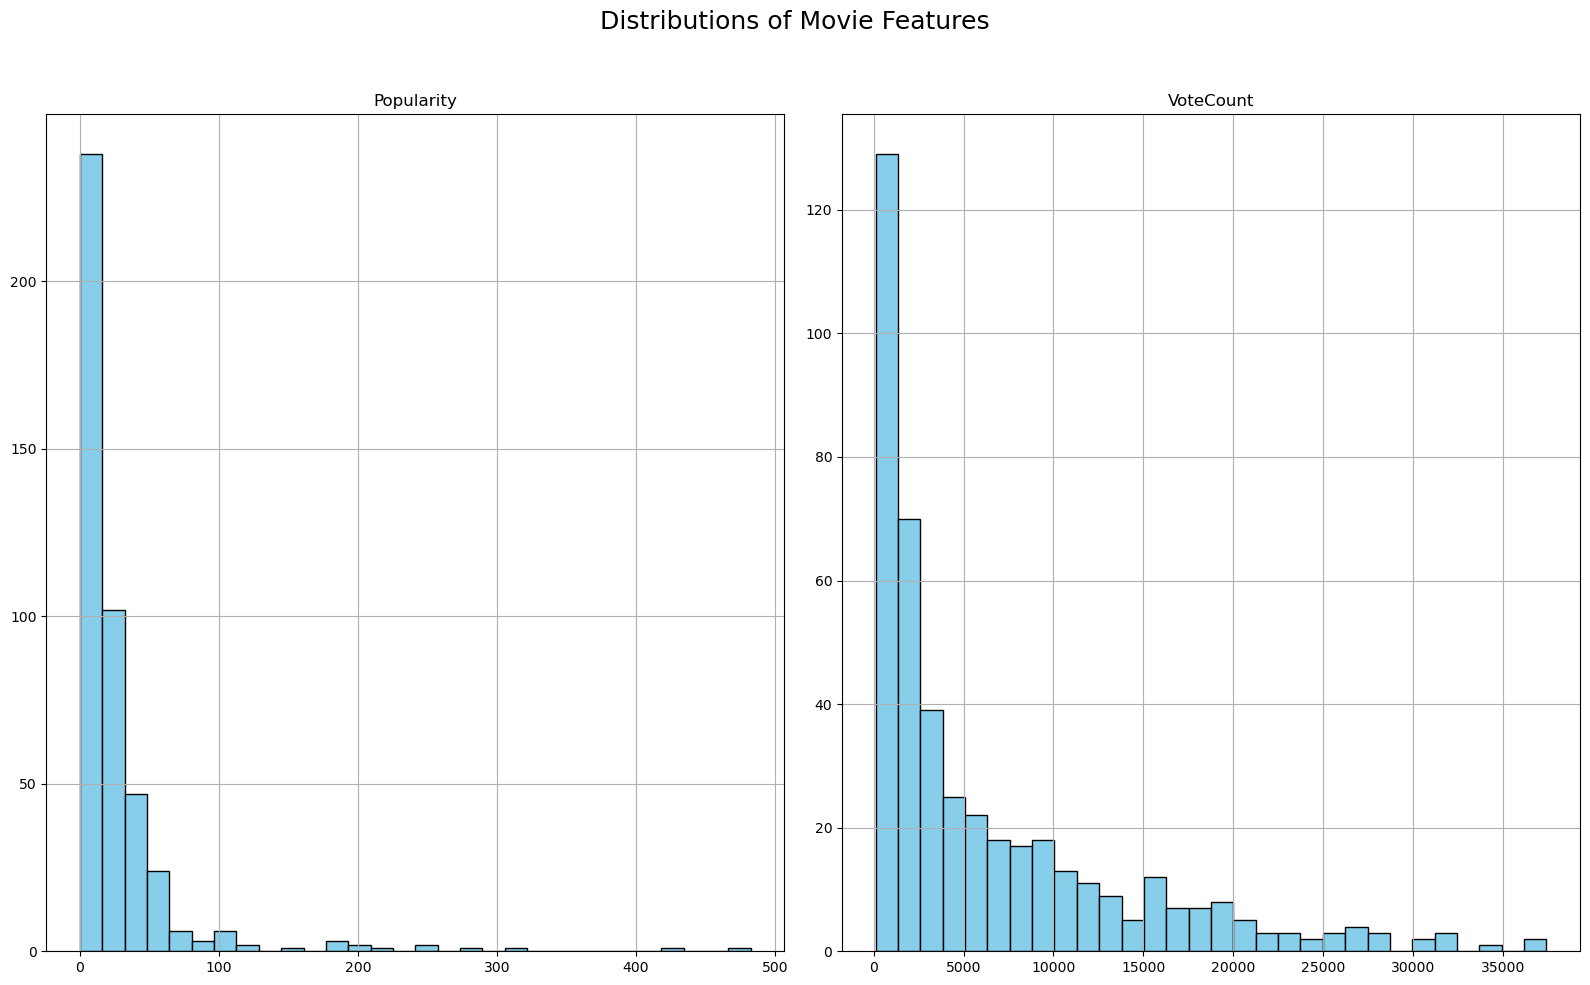

In [29]:
axes = movies[columns_of_choice].hist(
    bins=30,
    figsize=(16, 10),
    color='skyblue',
    edgecolor='black',
    layout=(1, 2)
)

plt.suptitle('Distributions of Movie Features', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [30]:
columns_of_choice = ['Budget', 'Revenue', 'Runtime']

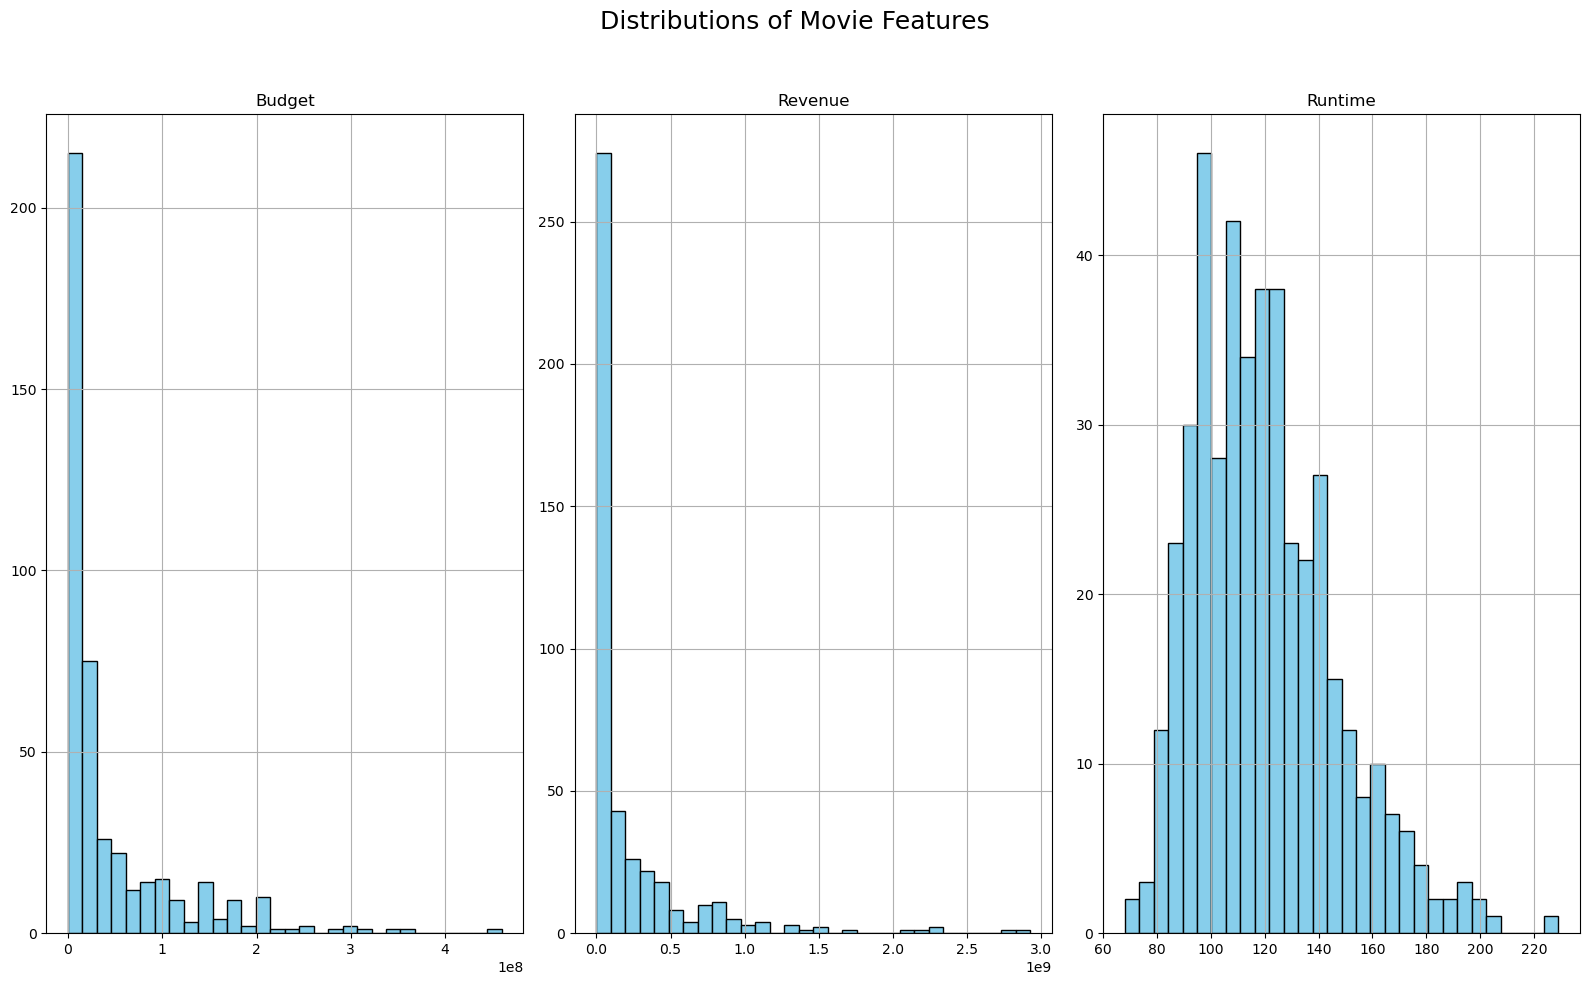

In [31]:
axes = movies[columns_of_choice].hist(
    bins=30,
    figsize=(16, 10),
    color='skyblue',
    edgecolor='black',
    layout=(1, 3)
)

plt.suptitle('Distributions of Movie Features', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Correlation Between Variables

In [33]:
numerical_cols = ['Popularity', 'VoteAverage', 'VoteCount', 'Budget', 'Revenue', 'Runtime', 'NumSpokenLanguages' ,'RedditSentimentWeighted', 'RottenTomatoesScore']

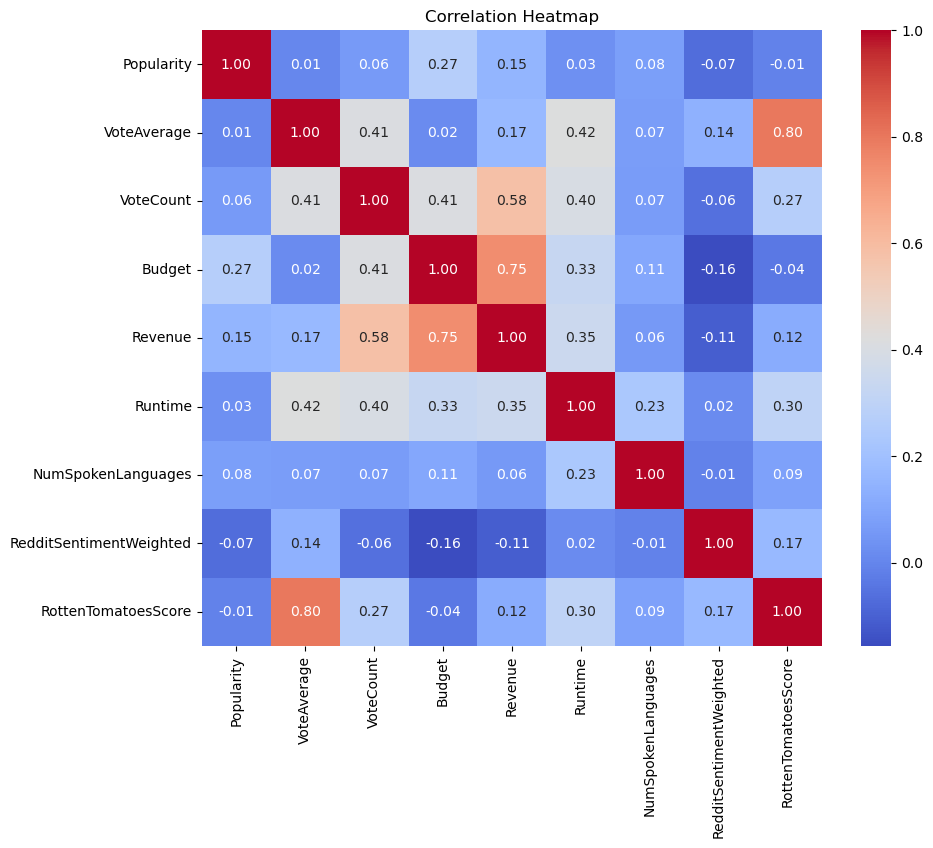

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(movies[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Scatter Plots Between Numerical Columns of Interest

In [36]:
numerical_cols = ['Popularity', 'VoteCount',  'Budget', 'Revenue', 'VoteAverage', 'RedditSentimentWeighted', 'RottenTomatoesScore']

In [37]:
def plot_scatter(df, target_col, numerical_cols, max_cols=3):

    other_cols = [col for col in numerical_cols if col != target_col]
    n = len(other_cols)
    ncols = 2
    nrows = 3

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    fig.suptitle(f'Scatter Plots: {target_col} vs Other Numerical Columns', fontsize=16)
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(other_cols):
        sns.scatterplot(data=df, x=target_col, y=col, ax=axes[i], alpha=0.6)
        axes[i].set_title(f'{target_col} vs {col}')

    for j in range(len(other_cols), len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

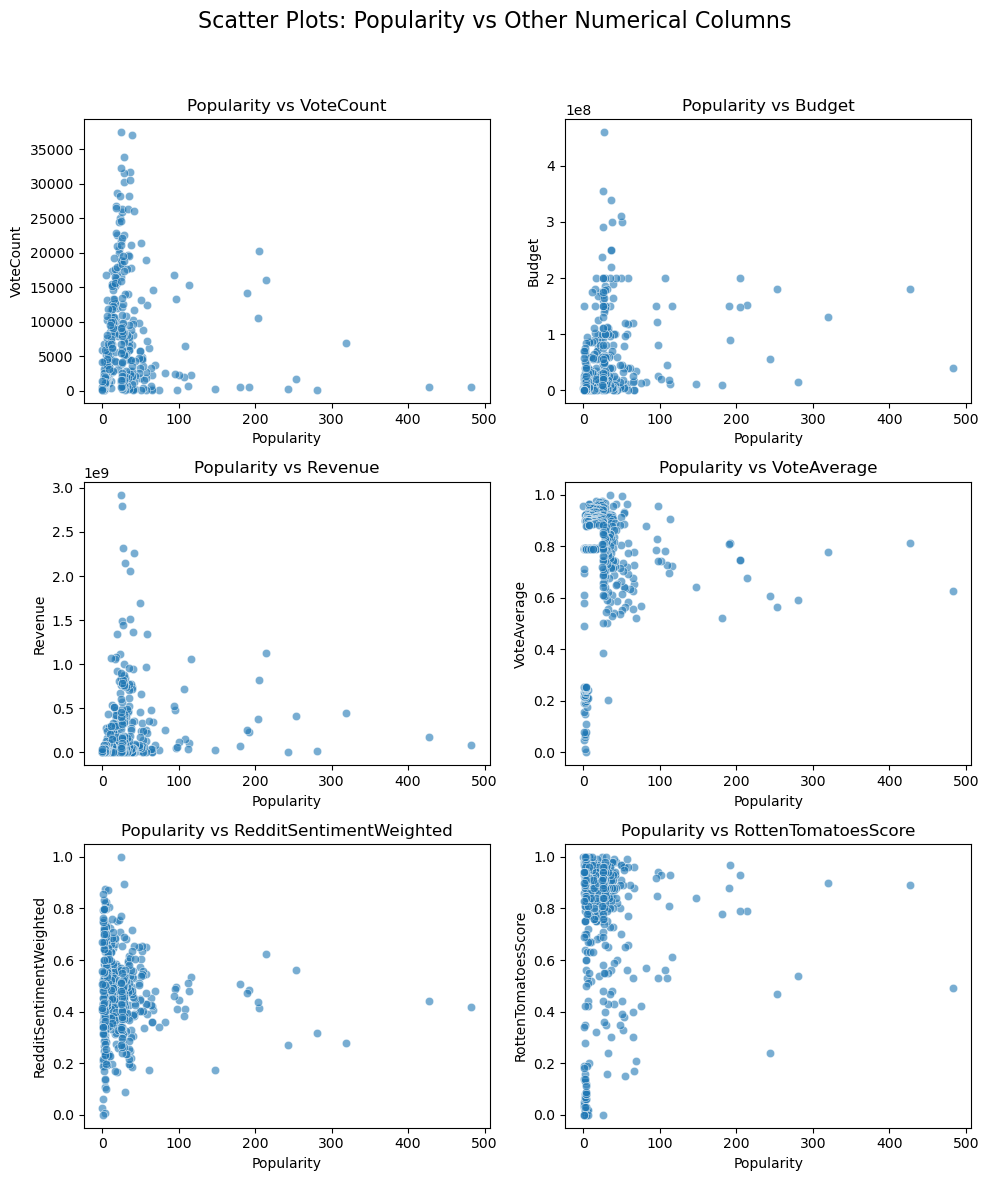

In [38]:
plot_scatter(movies, 'Popularity', numerical_cols)

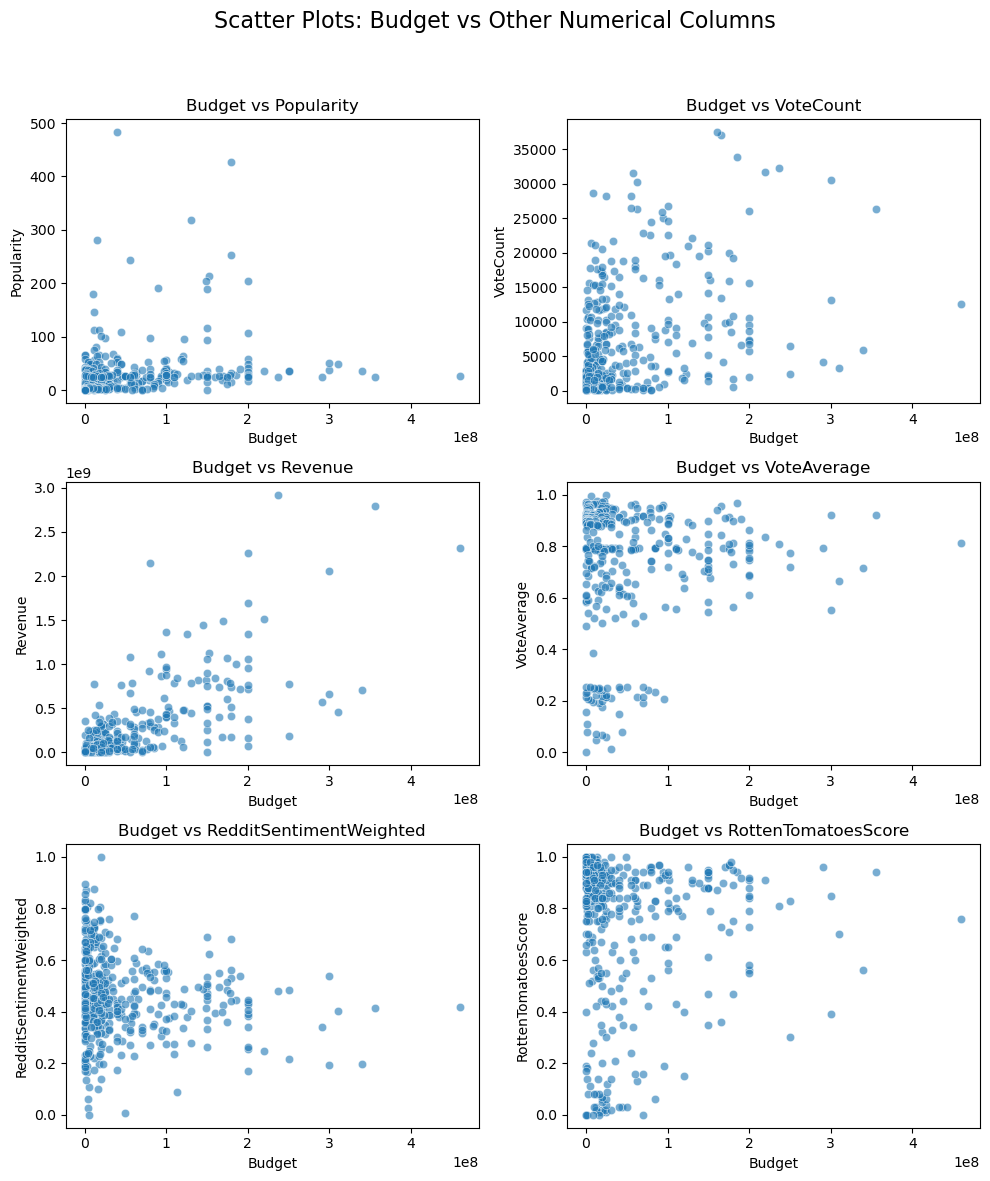

In [39]:
plot_scatter(movies, 'Budget', numerical_cols)

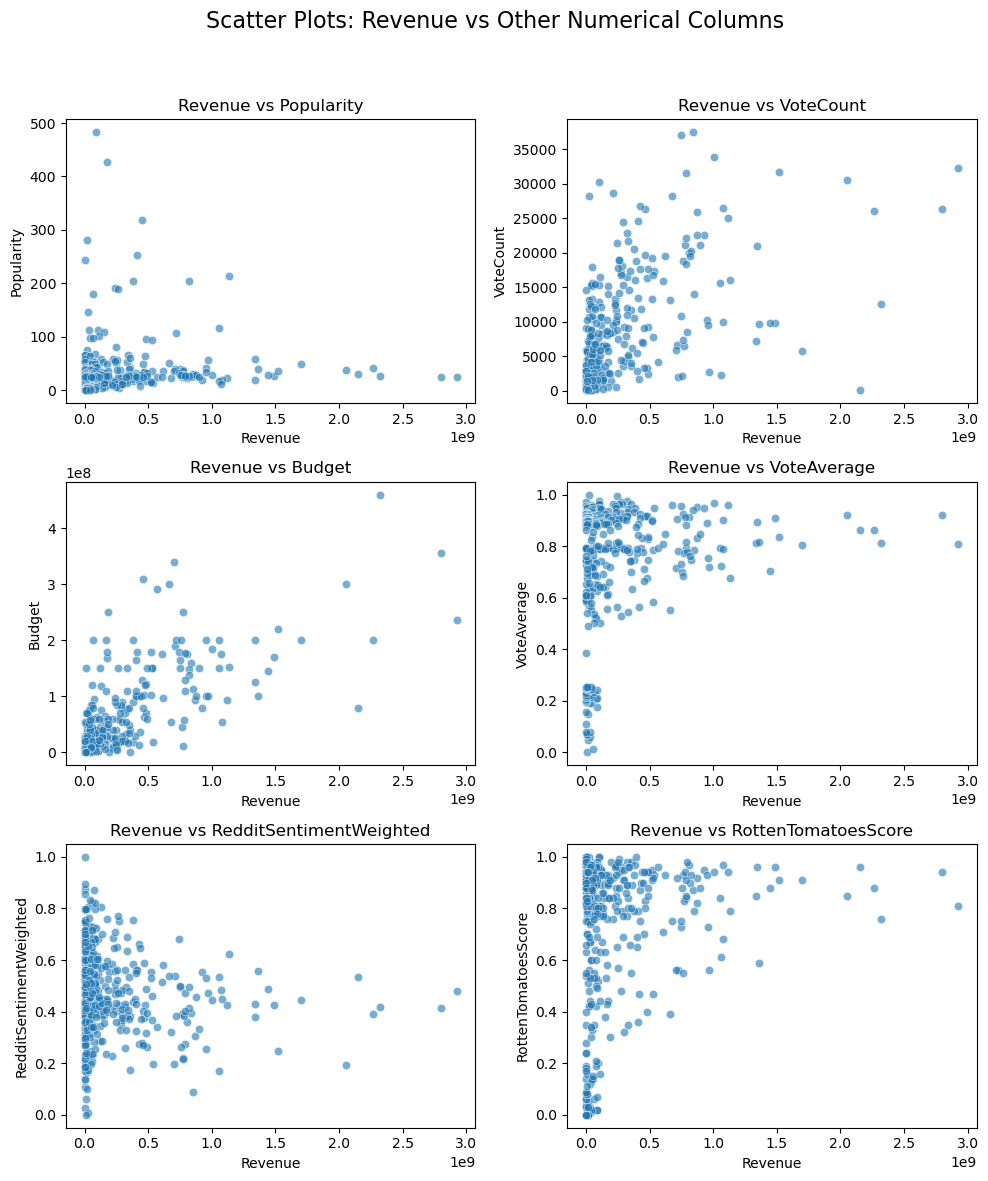

In [40]:
plot_scatter(movies, 'Revenue', numerical_cols)

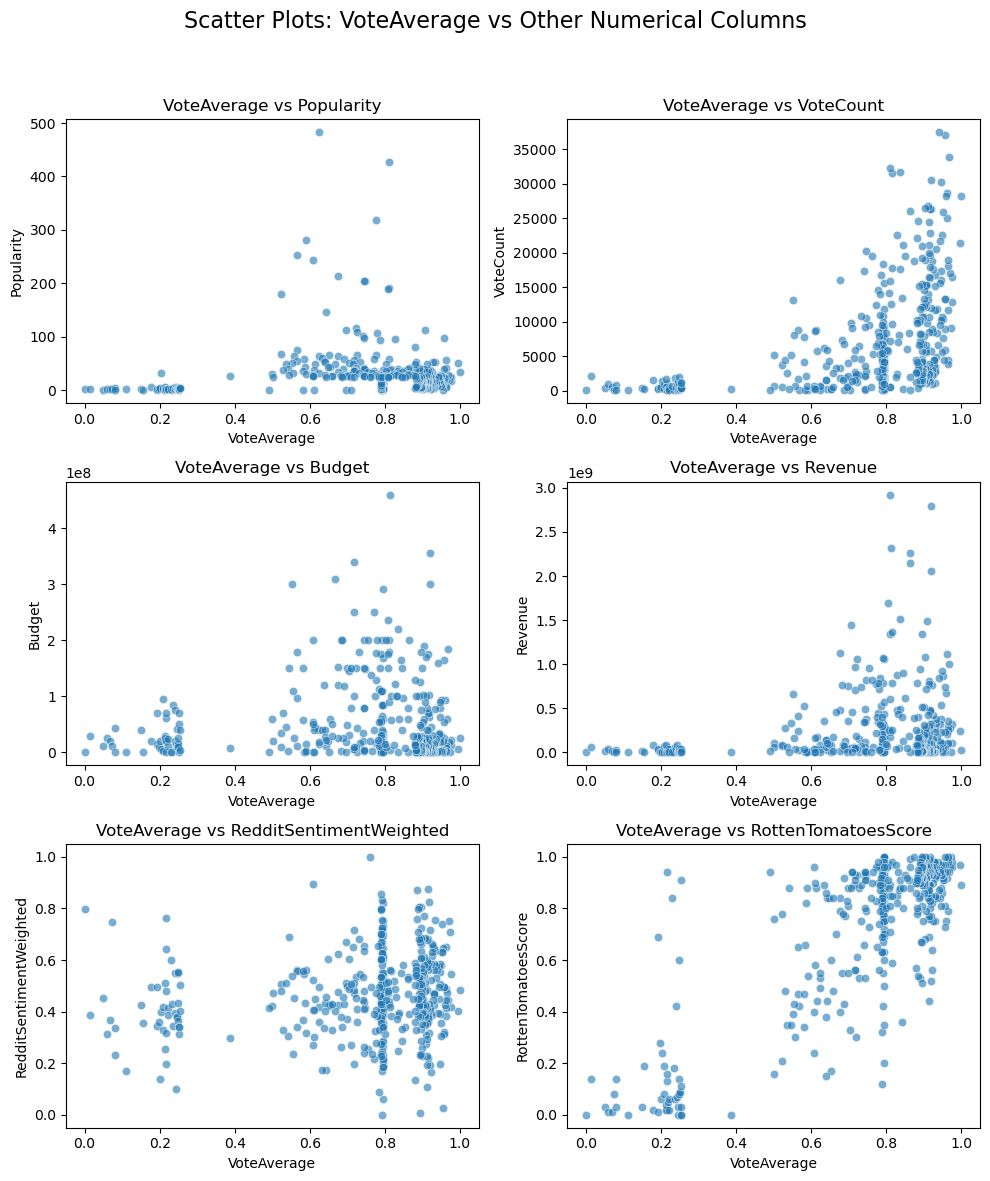

In [41]:
plot_scatter(movies, 'VoteAverage', numerical_cols)

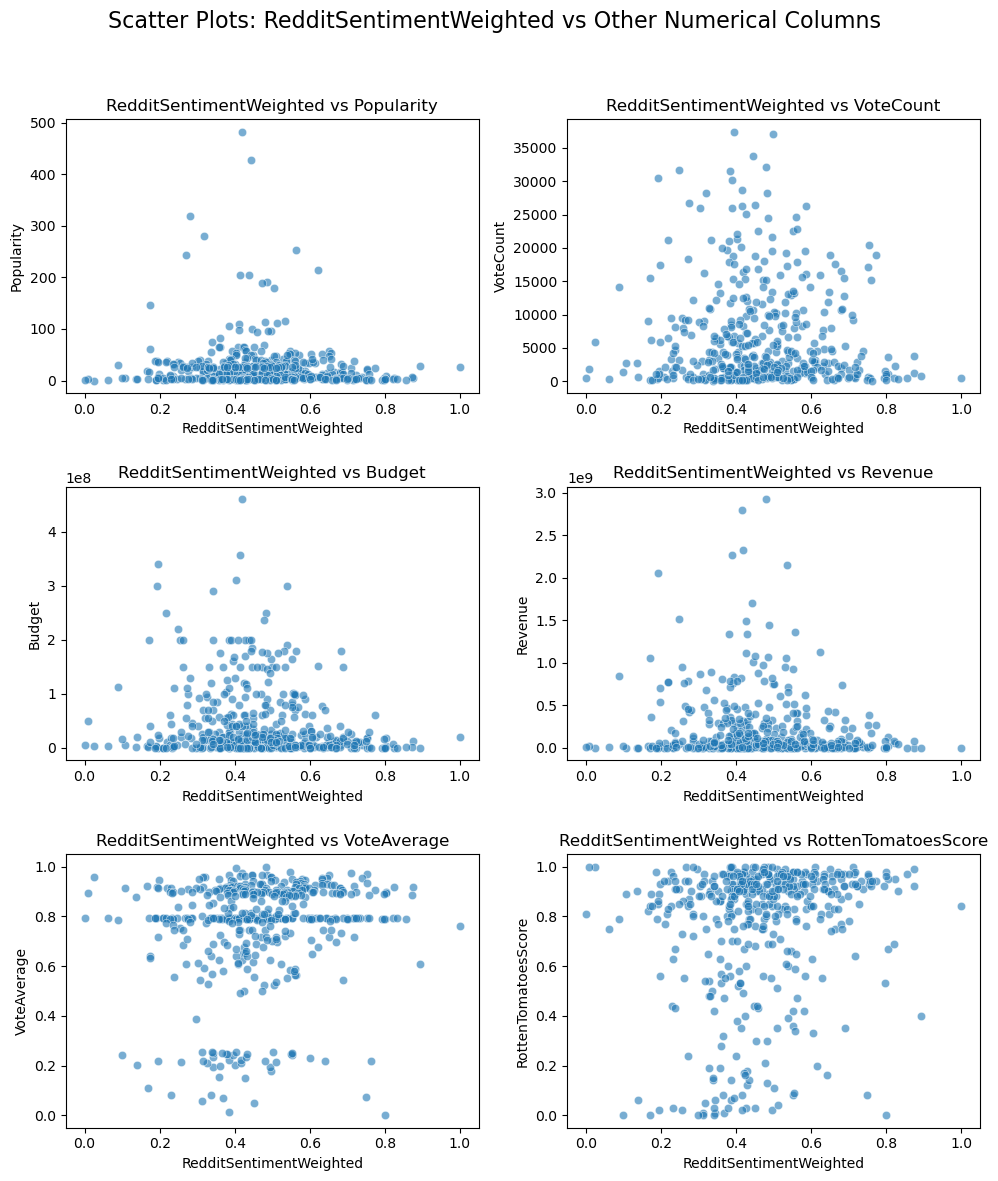

In [42]:
plot_scatter(movies, 'RedditSentimentWeighted', numerical_cols)

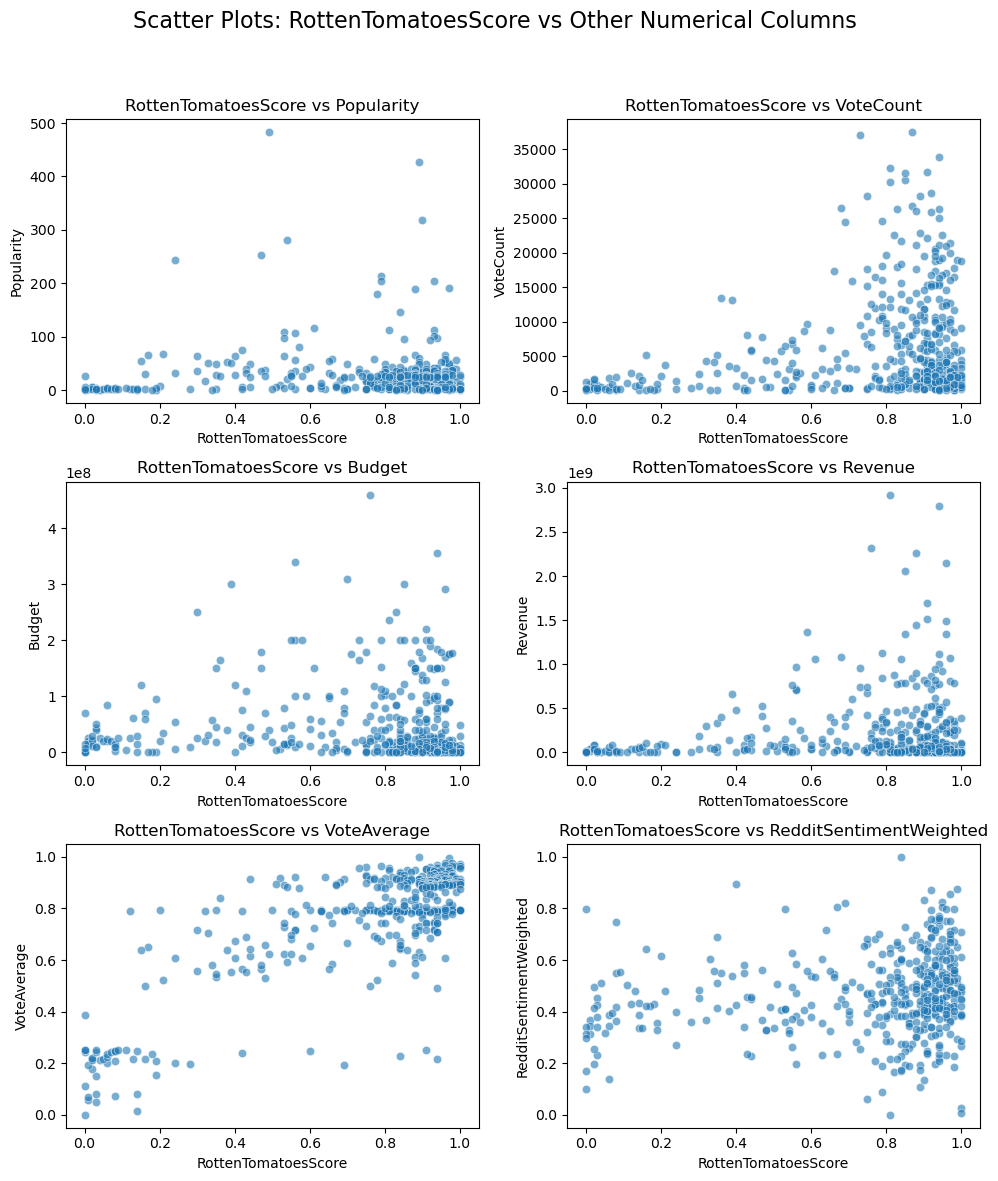

In [43]:
plot_scatter(movies, 'RottenTomatoesScore', numerical_cols)

### Popular Genres

In [45]:
import ast

# Fix stringified list columns
for col in ['Genres', 'OriginCountry', 'ProductionCompanies']:
    movies[col] = movies[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else [])

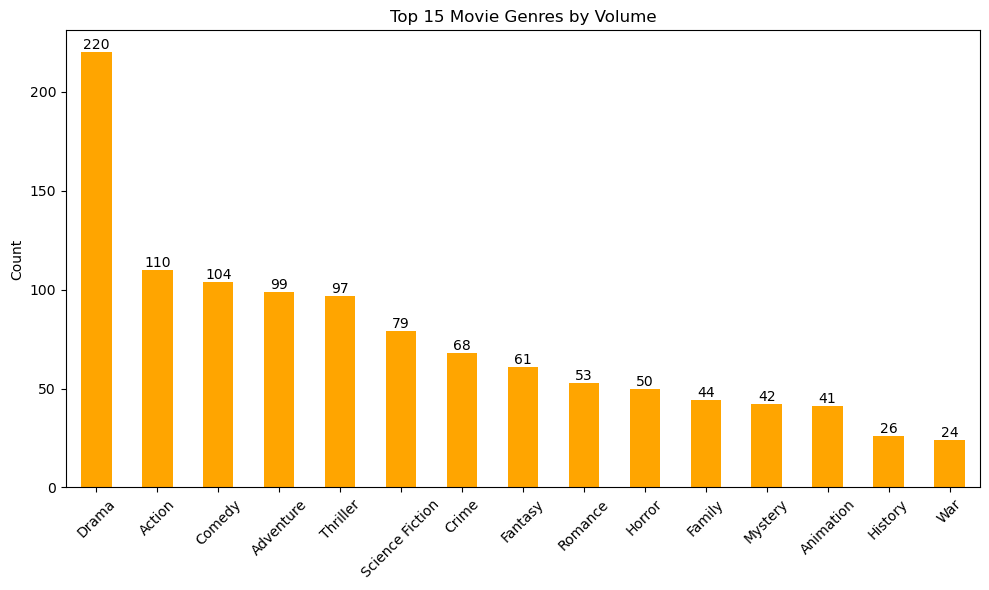

In [46]:
from collections import Counter

all_genres = [genre for sublist in movies['Genres'] for genre in sublist]
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False)


ax = genre_counts.head(15).plot(kind='bar', figsize=(10, 6), color='orange')
plt.title('Top 15 Movie Genres by Volume')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()


In [47]:
def plot_top_categories(df, category_col, score_col, title, xlabel, ylabel, top_n = 10, color = 'skyblue'):

    
    if df[category_col].apply(lambda x: isinstance(x, list)).any():
        df_exploded = df.explode(category_col)
    else:
        df_exploded = df.copy()

    
    avg_scores = df_exploded.groupby(category_col)[score_col].mean().sort_values(ascending=False).head(top_n)

    
    plt.figure(figsize=(12, 8))
    ax = avg_scores.plot(kind='bar', color=color)


    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.xticks(rotation=45)

    
    max_val = avg_scores.max()
    buffer = max_val * 0.05
    offset = max_val * 0.01
    plt.ylim(0, max_val + buffer)

    for i, v in enumerate(avg_scores):
        ax.text(
            i,
            v + offset,
            f"{v:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )


    plt.show()

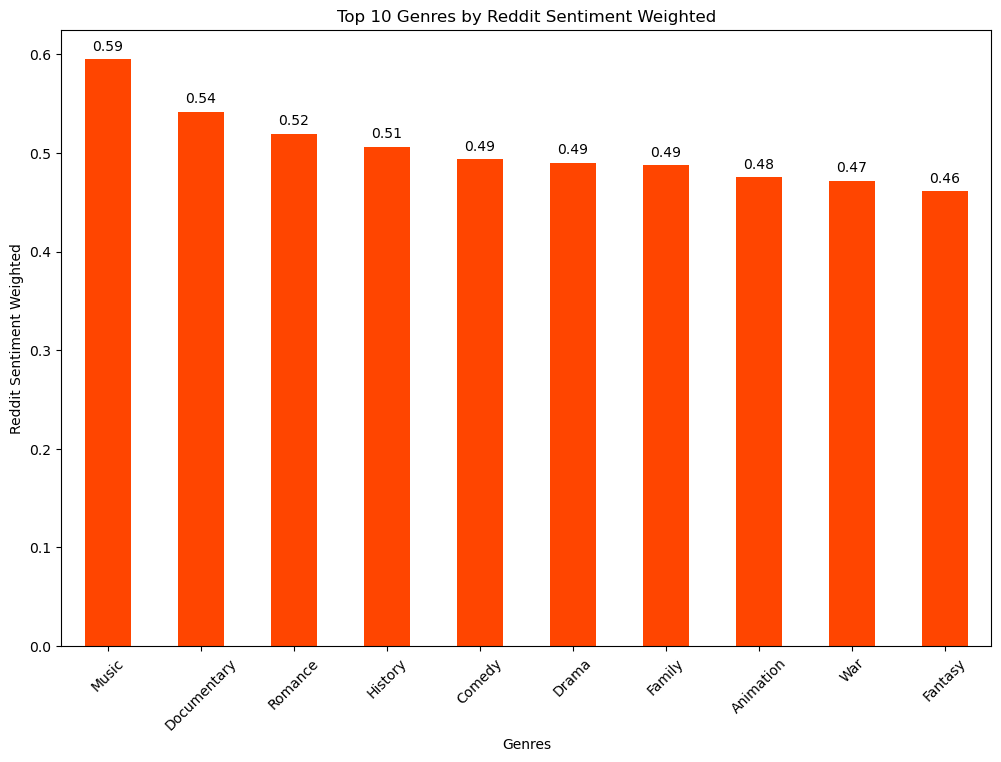

In [48]:
plot_top_categories(df = movies, 
                    category_col = 'Genres', 
                    score_col = 'RedditSentimentWeighted', 
                    title = 'Top 10 Genres by Reddit Sentiment Weighted', 
                    xlabel = 'Genres',
                    ylabel = 'Reddit Sentiment Weighted',  
                    color = 'orangered')

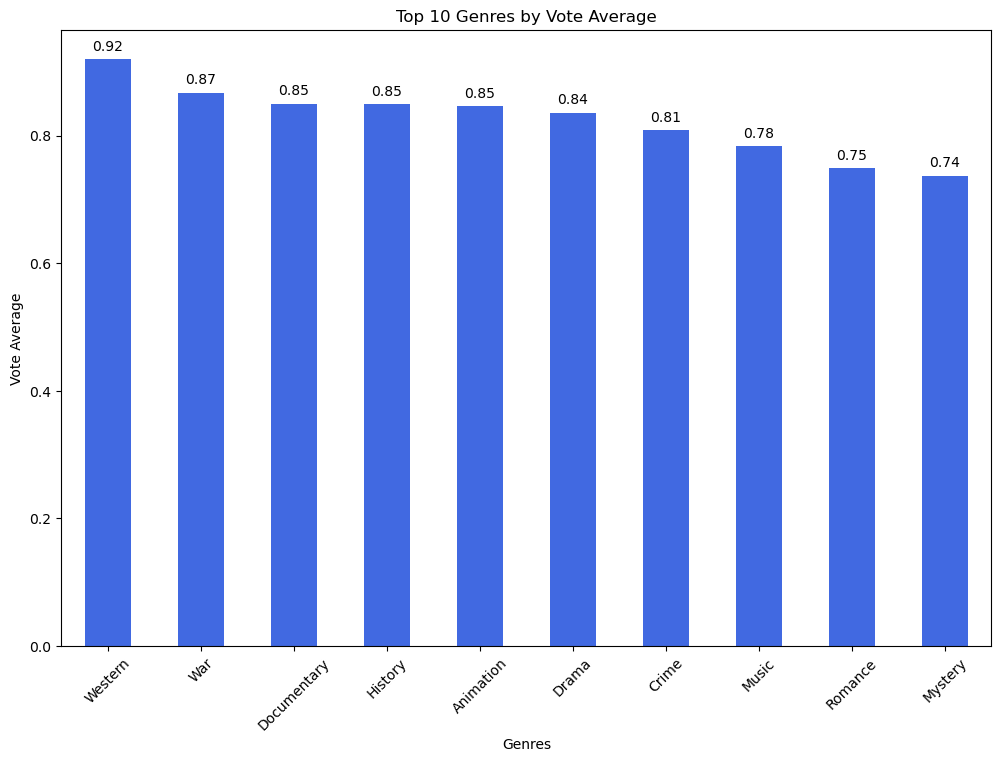

In [49]:
plot_top_categories(df = movies, 
                    category_col = 'Genres', 
                    score_col = 'VoteAverage', 
                    title = 'Top 10 Genres by Vote Average', 
                    xlabel = 'Genres',
                    ylabel = 'Vote Average', 
                    color='royalblue')

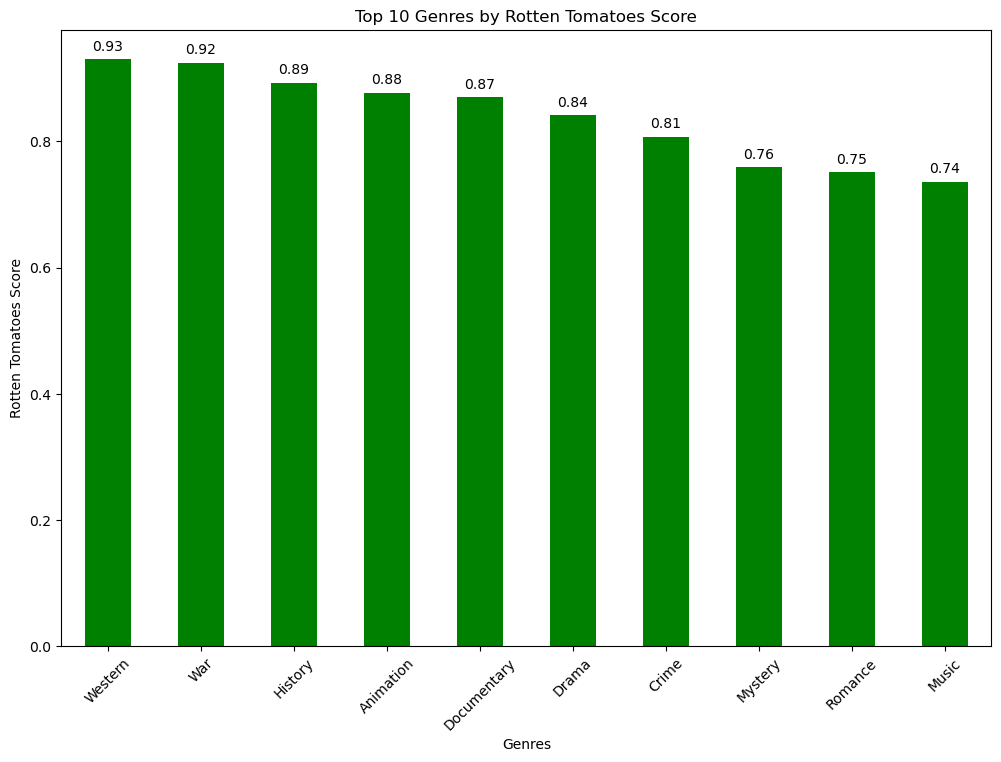

In [50]:
plot_top_categories(df = movies, 
                    category_col = 'Genres', 
                    score_col = 'RottenTomatoesScore', 
                    title = "Top 10 Genres by Rotten Tomatoes Score", 
                    xlabel = 'Genres',
                    ylabel = "Rotten Tomatoes Score", 
                    color = 'green')

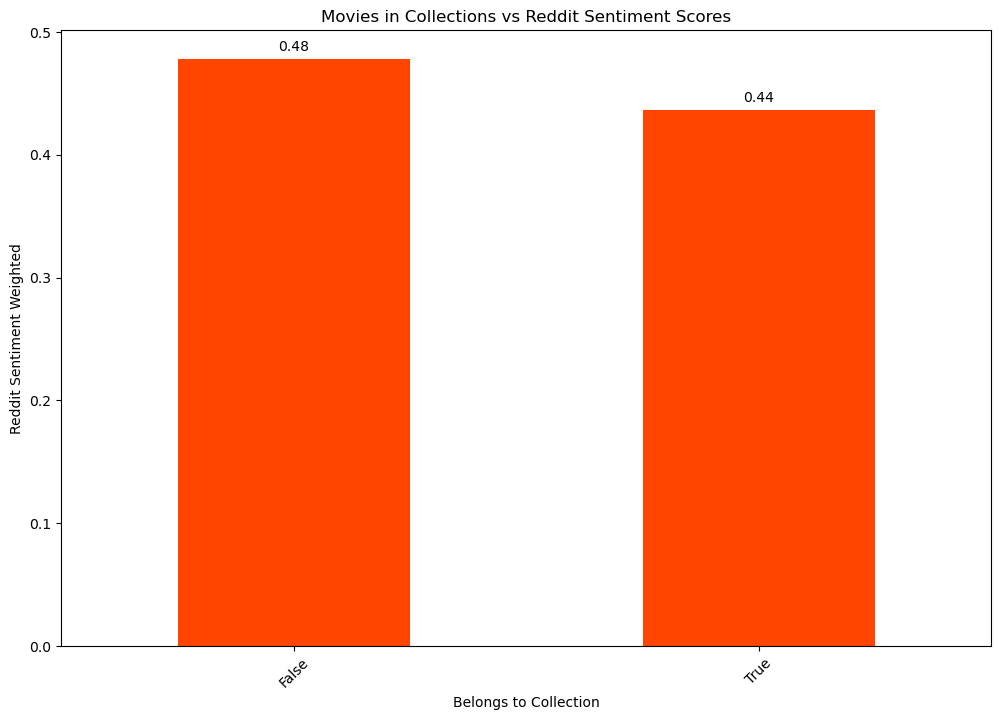

In [51]:
plot_top_categories(df = movies,
                   category_col = 'BelongsToCollectionBoolean',
                   score_col = 'RedditSentimentWeighted',
                   title = 'Movies in Collections vs Reddit Sentiment Scores',
                   xlabel = 'Belongs to Collection',
                   ylabel = 'Reddit Sentiment Weighted',
                   top_n = 2,
                   color = 'orangered')

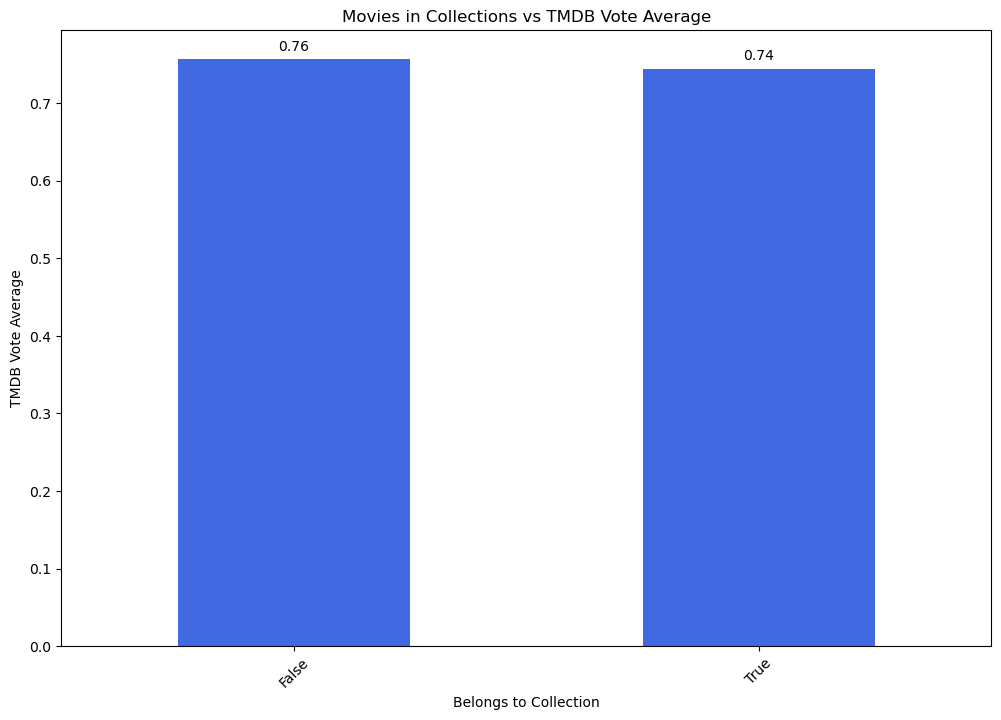

In [52]:
plot_top_categories(df = movies,
                   category_col = 'BelongsToCollectionBoolean',
                   score_col = 'VoteAverage',
                   title = 'Movies in Collections vs TMDB Vote Average',
                   xlabel = 'Belongs to Collection',
                   ylabel = 'TMDB Vote Average',
                   top_n = 2,
                   color = 'royalblue')

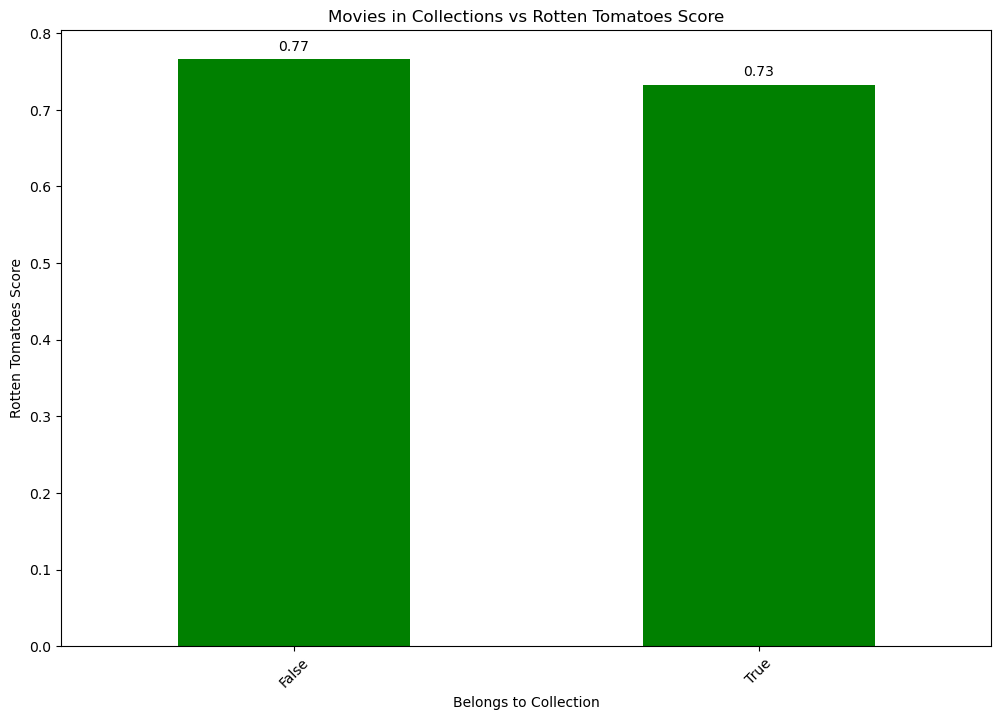

In [53]:
plot_top_categories(df = movies,
                   category_col = 'BelongsToCollectionBoolean',
                   score_col = 'RottenTomatoesScore',
                   title = 'Movies in Collections vs Rotten Tomatoes Score',
                   xlabel = 'Belongs to Collection',
                   ylabel = 'Rotten Tomatoes Score',
                   top_n = 2,
                   color = 'green')

## Predictive Modeling

#### Perform More Pre-processing

In [56]:
movies.columns

Index(['Adult', 'Id', 'OriginalLanguage', 'Overview', 'Popularity',
       'ReleaseDate', 'Title', 'VoteAverage', 'VoteCount',
       'BelongsToCollectionBoolean', 'Budget', 'Genres', 'OriginCountry',
       'ProductionCompanies', 'Revenue', 'Runtime', 'NumSpokenLanguages',
       'RedditSentimentWeighted', 'RottenTomatoesScore', 'ReleaseYear'],
      dtype='object')

In [57]:
df = movies.copy()

In [58]:
target = 'RottenTomatoesScore'

In [59]:
numerical_cols = ['Popularity', 'VoteAverage', 'VoteCount', 'Budget', 'Revenue', 'Runtime', 'NumSpokenLanguages' ,'RedditSentimentWeighted']

In [60]:
categorical_cols = ['OriginalLanguage']

In [61]:
boolean_cols = ['BelongsToCollectionBoolean']

In [62]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genres_encoded = pd.DataFrame(
    mlb.fit_transform(df['Genres']), 
    columns=mlb.classes_,
    index = df.index
)

df = pd.concat([df.drop(columns=['Genres']), genres_encoded], axis=1)

In [63]:
origin_country_encoded = pd.DataFrame(
    mlb.fit_transform(df['OriginCountry']),
    columns=[f"country_{c}" for c in mlb.classes_],
    index = df.index 
)

df = pd.concat([df.drop('OriginCountry', axis=1), origin_country_encoded], axis=1)


In [64]:
genre_cols = list(genres_encoded.columns)

In [65]:
origin_country_cols = list(origin_country_encoded.columns)

In [66]:
feature_cols = numerical_cols + categorical_cols + boolean_cols + genre_cols + origin_country_cols

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

preprocessor = ColumnTransformer(transformers = [
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('bool', 'passthrough', boolean_cols)
], remainder='drop')

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators = 100, random_state = 404))
])

In [68]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 404)

In [69]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [70]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
print("R^2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R^2 Score: 0.34049621104297
RMSE: 0.17484703330677298


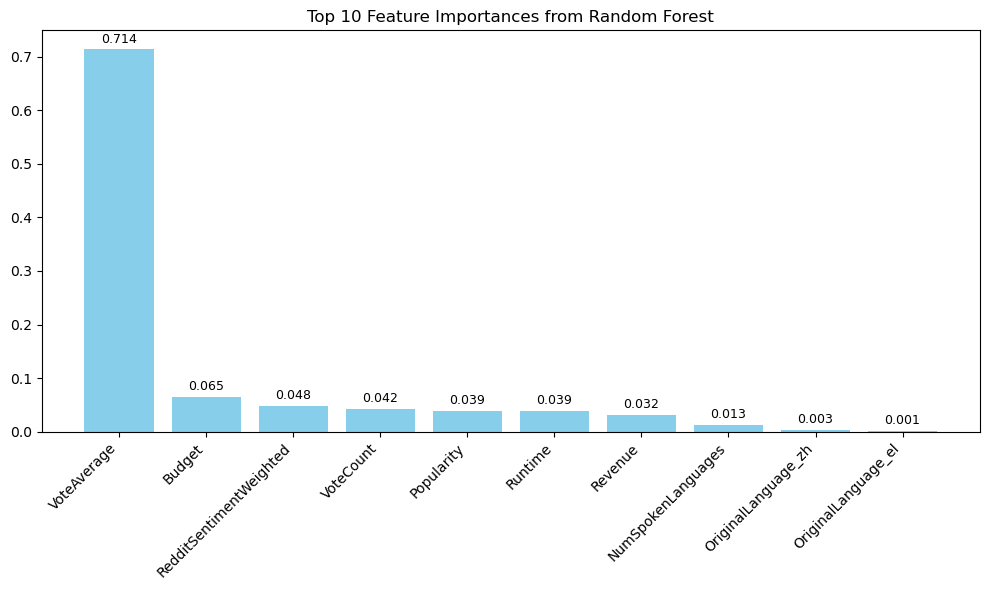

In [71]:
model = pipeline.named_steps['model']
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(categorical_cols))

num_bool_cols = numerical_cols + boolean_cols

final_feature_names = num_bool_cols + cat_feature_names + genre_cols + origin_country_cols

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 10
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_features = [final_feature_names[i] for i in top_indices]

plt.figure(figsize=(10, 6))
plt.title(f"Top {top_n} Feature Importances from Random Forest")
bars = plt.bar(range(top_n), top_importances, align='center', color='skyblue')
plt.xticks(range(top_n), top_features, rotation=45, ha='right')

# Add numbers on top of the bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + top_importances.max() * 0.01,  # small offset above the bar
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [72]:
from sklearn.model_selection import cross_val_score, KFold


kf = KFold(n_splits = 10, shuffle = True, random_state = 404)

cv_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')

print(f"Cross-validation R^2 scores: {cv_scores}")
print(f"Mean CV R^2: {np.mean(cv_scores):.4f}")
print(f"Std CV R^2: {np.std(cv_scores):.4f}")

Cross-validation R^2 scores: [0.34572581 0.41581892 0.49058025 0.68488131 0.86375638 0.60681172
 0.53620422 0.6265203  0.40890889 0.59094588]
Mean CV R^2: 0.5570
Std CV R^2: 0.1450


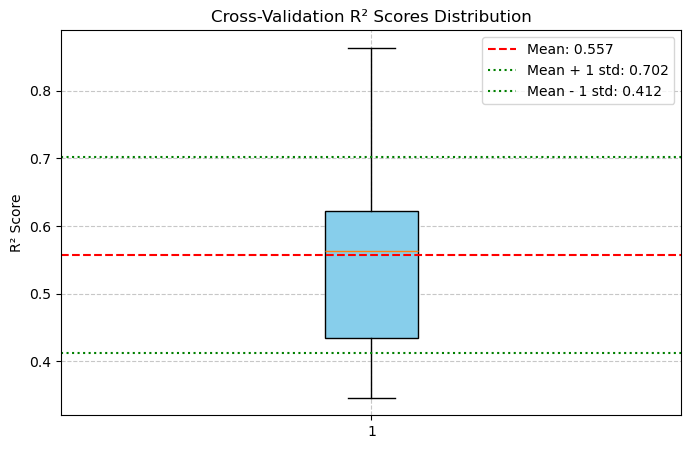

In [73]:
mean_score = np.mean(cv_scores)
std_score = np.std(cv_scores)

plt.figure(figsize=(8,5))
plt.boxplot(cv_scores, vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.axhline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.3f}')
plt.axhline(mean_score + std_score, color='green', linestyle=':', label=f'Mean + 1 std: {mean_score + std_score:.3f}')
plt.axhline(mean_score - std_score, color='green', linestyle=':', label=f'Mean - 1 std: {mean_score - std_score:.3f}')
plt.title('Cross-Validation R² Scores Distribution')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

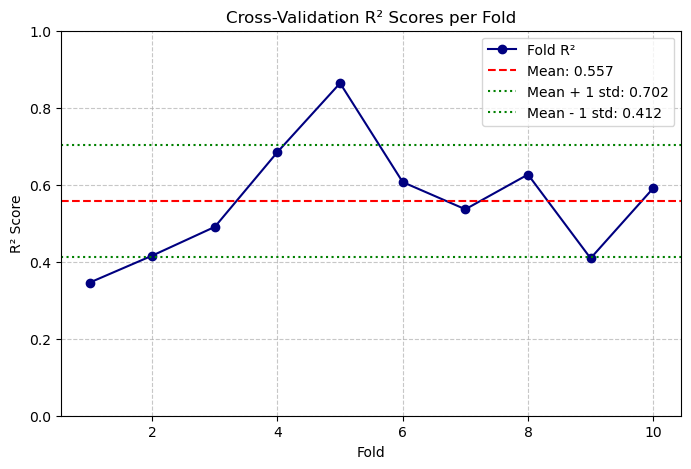

In [74]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cv_scores)+1), cv_scores, marker='o', linestyle='-', color='navy', label='Fold R²')
plt.axhline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.3f}')
plt.axhline(mean_score + std_score, color='green', linestyle=':', label=f'Mean + 1 std: {mean_score + std_score:.3f}')
plt.axhline(mean_score - std_score, color='green', linestyle=':', label=f'Mean - 1 std: {mean_score - std_score:.3f}')
plt.title('Cross-Validation R² Scores per Fold')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [75]:
import ctypes
from scipy.stats import iqr

lib = ctypes.CDLL('./nwRegression.dll')
lib.nW_kre.argtypes = [
    ctypes.POINTER(ctypes.c_int),
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double)
]

In [76]:
def nadaraya_watson_c(X, Y, g2):
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    g2 = np.asarray(g2, dtype=np.float64)

    n = ctypes.c_int(len(X))
    m = ctypes.c_int(len(g2))

    std_dev = np.std(X, ddof=1)
    scale = min(std_dev, iqr(X) / 1.34)
    h_val = 1.06 * scale * len(X) ** (-0.2)
    h = ctypes.c_double(h_val)

    res2 = np.zeros_like(g2)

    lib.nW_kre(
        ctypes.byref(n),
        X.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.byref(m),
        g2.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        res2.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.byref(h)
    )

    return res2

In [77]:
def bootstrap_nw_ci(X, Y, g2, n_boot=200, sample_size=len(X), ci=95, seed=404):
    rng = np.random.default_rng(seed)
    k = len(g2)
    kre_matrix = np.empty((n_boot, k))

    for i in range(n_boot):
        idx = rng.choice(len(X), size=sample_size, replace=True)
        xi = X[idx]
        yi = Y[idx]
        kre_matrix[i] = nadaraya_watson_c(xi, yi, g2)

    lower = np.percentile(kre_matrix, 2.5, axis=0)
    upper = np.percentile(kre_matrix, 97.5, axis=0)

    return kre_matrix, lower, upper

In [78]:
X = df['VoteAverage'].to_numpy()
Y = df['RottenTomatoesScore'].to_numpy()
g2 = np.linspace(X.min(), X.max(), 500)

result = nadaraya_watson_c(X, Y, g2)
kre_m, lower_bound, upper_bound = bootstrap_nw_ci(X, Y, g2)

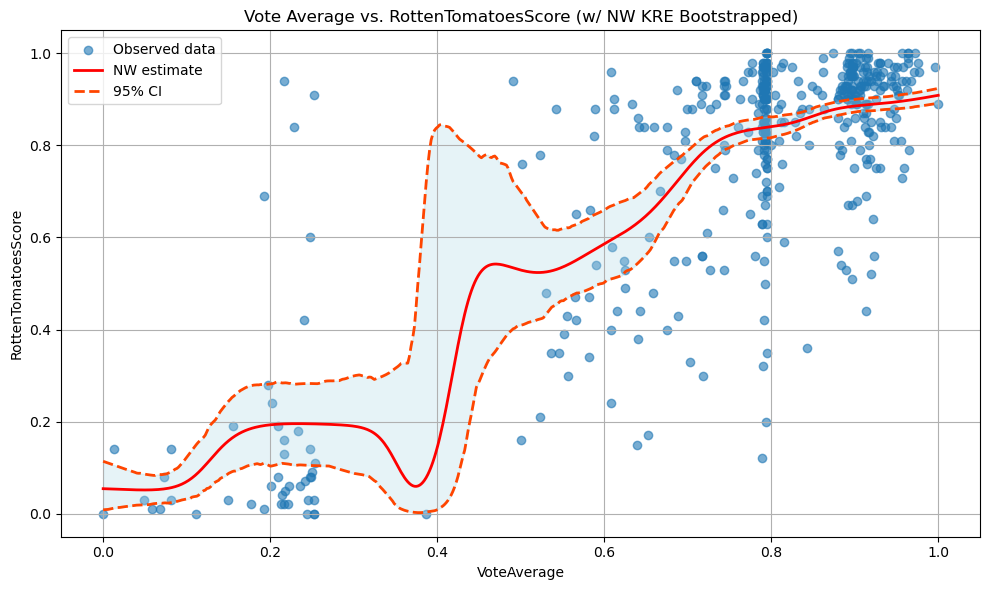

In [161]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.6, label="Observed data")
plt.plot(g2, result, color="red", lw=2, label="NW estimate")
plt.plot(g2, lower_bound, color="orangered", lw=2, ls='--', label="95% CI")
plt.plot(g2, upper_bound, color="orangered", lw=2, ls='--')
plt.fill_between(g2, lower_bound, upper_bound, color="lightblue", alpha=0.3)

plt.xlabel("VoteAverage")
plt.ylabel("RottenTomatoesScore")
plt.title("Vote Average vs. RottenTomatoesScore (w/ NW KRE Bootstrapped)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [163]:
X = df['RedditSentimentWeighted'].to_numpy()
Y = df['RottenTomatoesScore'].to_numpy()
g2 = np.linspace(X.min(), X.max(), 500)

result = nadaraya_watson_c(X, Y, g2)
kre_m, lower_bound, upper_bound = bootstrap_nw_ci(X, Y, g2)

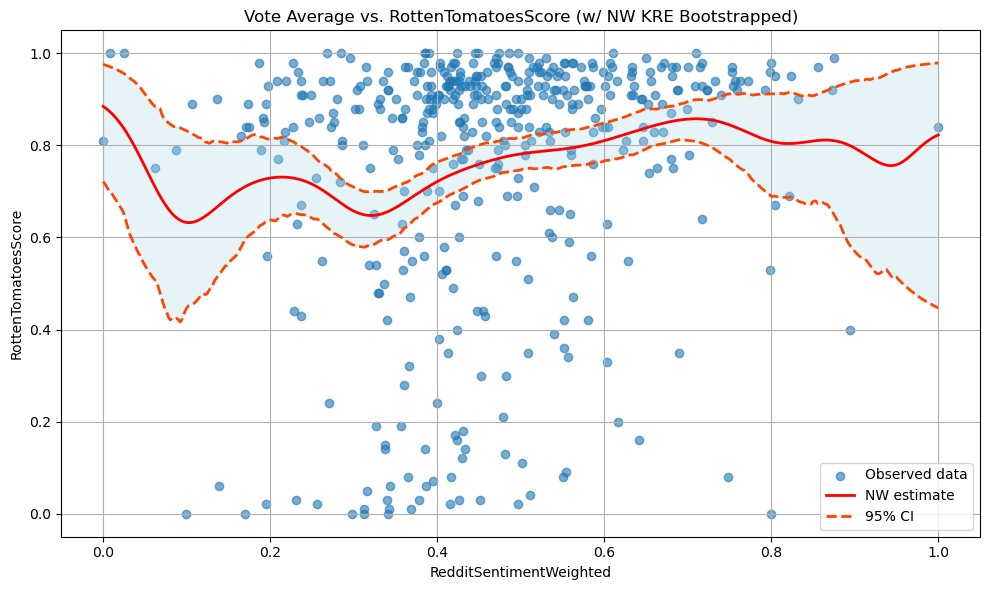

In [164]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.6, label="Observed data")
plt.plot(g2, result, color="red", lw=2, label="NW estimate")
plt.plot(g2, lower_bound, color="orangered", lw=2, ls='--', label="95% CI")
plt.plot(g2, upper_bound, color="orangered", lw=2, ls='--')
plt.fill_between(g2, lower_bound, upper_bound, color="lightblue", alpha=0.3)

plt.xlabel("RedditSentimentWeighted")
plt.ylabel("RottenTomatoesScore")
plt.title("Vote Average vs. RottenTomatoesScore (w/ NW KRE Bootstrapped)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
